In [18]:
# =============================================================================
# 1：环境配置和库导入
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

# 机器学习库
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

# 关联规则
from mlxtend.frequent_patterns import apriori, association_rules

# 可视化设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

print("环境配置完成")

环境配置完成


In [19]:
# =============================================================================
# 2：数据加载
# =============================================================================
df = pd.read_excel('Online Retail.xlsx')
print(f"数据形状: {df.shape}")
print("数据前5行预览:")
df.head().style\
    .set_caption('表0-1 原始数据样本')\
    .format({'Quantity': '{:.0f}', 'UnitPrice': '£{:.2f}', 'CustomerID': '{:.0f}'})\
    .background_gradient(subset=['Quantity', 'UnitPrice'], cmap='Blues')\
    .set_properties(**{'text-align': 'center'})

数据形状: (541909, 8)
数据前5行预览:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,£2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,£3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,£2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,£3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,£3.39,17850,United Kingdom


In [20]:
# =============================================================================
# 3：任务1.1 - 数据清洗（缺失值、异常值处理）
# =============================================================================
print("开始任务1.1 数据清洗")

original_shape = df.shape
# 删除CustomerID缺失记录
df_clean = df.dropna(subset=['CustomerID'])

# 删除异常值（负数量和0单价订单）
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 删除退货订单
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 日期格式转换
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 计算总金额
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"清洗完成: 原始数据{original_shape[0]}条 → 清洗后{df_clean.shape[0]}条")
print("清洗后数据统计描述:")
df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].describe().style\
    .set_caption('表1-1 数值变量统计描述表')\
    .format({'count': '{:,.0f}', 'mean': '{:.2f}', 'std': '{:.2f}', 
             'min': '{:.2f}', '25%': '{:.2f}', '50%': '{:.2f}', 
             '75%': '{:.2f}', 'max': '{:.2f}'})\
    .background_gradient(cmap='Blues')\
    .set_properties(**{'text-align': 'center'})

开始任务1.1 数据清洗
清洗完成: 原始数据541909条 → 清洗后397884条
清洗后数据统计描述:


,Quantity,UnitPrice,TotalAmount
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [21]:
# =============================================================================
# 4：任务1.2 - 用户级特征工程（RFM+时间偏好）
# =============================================================================
print("开始任务1.2 用户级特征工程")

# 设置分析基准日期
snapshot_date = df_clean['InvoiceDate'].max() + timedelta(days=1)

# 计算RFM特征
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency最近购买天数
    'InvoiceNo': 'nunique',                                  # Frequency购买次数  
    'TotalAmount': 'sum'                                     # Monetary总消费金额
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# 计算购买时段偏好
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['TimeSegment'] = pd.cut(df_clean['Hour'], 
                               bins=[0, 6, 12, 18, 24],
                               labels=['深夜', '上午', '下午', '晚上'],
                               right=False)

# 计算各时段购买比例
time_pref = df_clean.groupby(['CustomerID', 'TimeSegment']).size().unstack(fill_value=0)
time_pref = time_pref.div(time_pref.sum(axis=1), axis=0)

# 重置索引，确保CustomerID是列而不是索引
time_pref = time_pref.reset_index()

# 合并所有用户特征
user_features = pd.merge(rfm, time_pref, on='CustomerID', how='left').fillna(0)

print("用户特征工程完成")
print(f"用户特征数据形状: {user_features.shape}")
user_features.head().style\
    .set_caption('表1-2 用户特征数据示例表')\
    .format({
        'Recency': '{:.0f}天', 
        'Frequency': '{:.0f}次', 
        'Monetary': '¥{:,.2f}',
        '深夜': '{:.1%}', '上午': '{:.1%}', '下午': '{:.1%}', '晚上': '{:.1%}'
    })\
    .background_gradient(subset=['Recency', 'Frequency', 'Monetary'], cmap='YlGnBu')\
    .background_gradient(subset=['深夜', '上午', '下午', '晚上'], cmap='YlOrRd')\
    .set_properties(**{'text-align': 'center', 'font-size': '11px'})

开始任务1.2 用户级特征工程
用户特征工程完成
用户特征数据形状: (4338, 8)


,CustomerID,Recency,Frequency,Monetary,深夜,上午,下午,晚上
0,12346.000000,326天,1次,"¥77,183.60",0.0%,100.0%,0.0%,0.0%
1,12347.000000,2天,7次,"¥4,310.00",0.0%,25.3%,74.7%,0.0%
2,12348.000000,75天,4次,"¥1,797.24",0.0%,35.5%,9.7%,54.8%
3,12349.000000,19天,1次,"¥1,757.55",0.0%,100.0%,0.0%,0.0%
4,12350.000000,310天,1次,¥334.40,0.0%,0.0%,100.0%,0.0%


In [22]:
# =============================================================================
# 5：任务1.3 - 商品级特征
# =============================================================================
print("开始任务1.3 商品级特征")

product_features = df_clean.groupby('StockCode').agg({
    'InvoiceNo': 'nunique',      # 商品被购买频次
    'Quantity': ['mean', 'sum'],  # 平均订单量、总销量
    'CustomerID': 'nunique'       # 购买用户数
}).round(2)

product_features.columns = ['购买频次', '平均订单量', '总销量', '购买用户数']
print("商品特征构造完成")
product_features.head().style\
    .set_caption('表1-3 商品特征数据示例表')\
    .format({
        '购买频次': '{:.0f}次',
        '平均订单量': '{:.2f}件', 
        '总销量': '{:,.0f}件',
        '购买用户数': '{:.0f}人'
    })\
    .background_gradient(subset=['购买频次', '总销量', '购买用户数'], cmap='YlGnBu')\
    .background_gradient(subset=['平均订单量'], cmap='YlOrRd')\
    .set_properties(**{'text-align': 'center', 'font-size': '11px'})

开始任务1.3 商品级特征
商品特征构造完成


,购买频次,平均订单量,总销量,购买用户数
StockCode,,,,
10002,49次,16.80件,823件,40人
10080,21次,13.86件,291件,19人
10120,29次,6.43件,193件,25人
10125,61次,19.16件,"1,226件",49人
10133,122次,19.23件,"2,384件",101人


In [23]:
# =============================================================================
# 6：任务2.1 - 关联规则挖掘
# =============================================================================
print("开始任务2.1 关联规则挖掘")

# 准备交易篮数据
basket = df_clean.groupby(['InvoiceNo', 'StockCode'])['Quantity'].sum().unstack().fillna(0)
basket_binary = (basket > 0).astype(bool)

# 提高最小支持度减少计算量
frequent_itemsets = apriori(basket_binary, min_support=0.01, use_colnames=True, max_len=2, low_memory=True)

# 生成关联规则
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)

print(f"生成关联规则数量: {len(rules)}条")
print("前5条强关联规则:")
# 转换为字符串格式
top_rules = rules.head(5)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: str(set(x)).replace('{', '').replace('}', ''))
top_rules['consequents'] = top_rules['consequents'].apply(lambda x: str(set(x)).replace('{', '').replace('}', ''))

display(top_rules.style
    .set_caption('表1-3 前5条关联规则表')
    .format({
        'support': '{:.4f}',
        'confidence': '{:.4f}',
        'lift': '{:.2f}'
    })
    .background_gradient(subset=['support', 'confidence', 'lift'], cmap='Blues')
    .set_properties(**{'text-align': 'center'}))

开始任务2.1 关联规则挖掘
生成关联规则数量: 146条
前5条强关联规则:


,antecedents,consequents,support,confidence,lift
105,23172,23171,0.0109,0.9018,61.90
104,23171,23172,0.0109,0.7481,61.90
111,23175,23174,0.0111,0.7574,52.37
110,23174,23175,0.0111,0.7687,52.37
102,23170,23172,0.0106,0.6006,49.69


开始任务2.2 用户分群


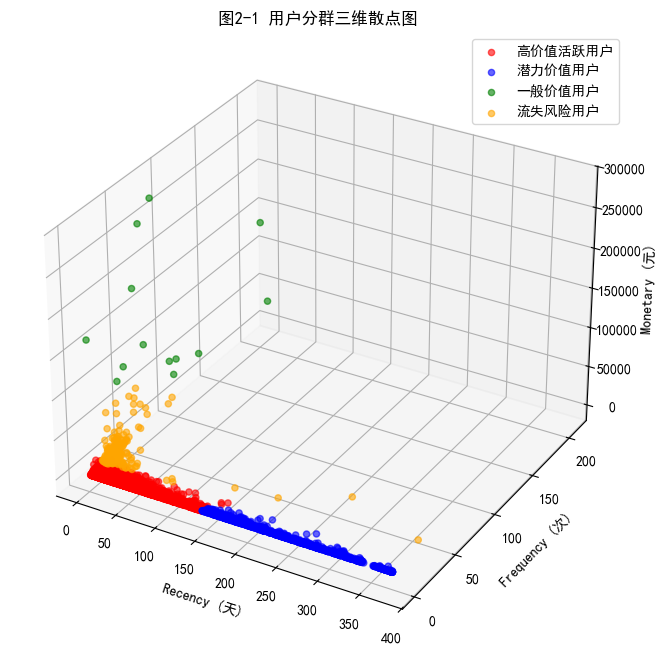

用户群体定义表:


,用户类型,用户数量,Recency均值,Frequency均值,Monetary均值,占比,特征描述
0,一般价值用户,13,7.4天,82.5次,"¥127,338",0.3%,低频次、一般价值
1,流失风险用户,204,15.5天,22.3次,"¥12,709",4.7%,长期未购、流失风险高
2,潜力价值用户,"1,067",248.1天,1.6次,¥481,24.6%,中等活跃、有提升空间
3,高价值活跃用户,"3,054",43.7天,3.7次,"¥1,359",70.4%,近期活跃、高频高价值


用户分群完成


In [24]:
# =============================================================================
# 7：任务2.2 - K-Means用户分群
# =============================================================================
print("开始任务2.2 用户分群")

# 数据标准化
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(user_features[['Recency', 'Frequency', 'Monetary']])

# K-Means聚类
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
user_features['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 定义用户标签
cluster_labels = {0: '高价值活跃用户', 1: '潜力价值用户', 
                  2: '一般价值用户', 3: '流失风险用户'}
user_features['Cluster_Label'] = user_features['Cluster'].map(cluster_labels)

# 三维散点图可视化
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    cluster_data = user_features[user_features['Cluster'] == i]
    ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], 
               cluster_data['Monetary'], c=colors[i], 
               label=cluster_labels[i], alpha=0.6)

ax.set_xlabel('Recency (天)')
ax.set_ylabel('Frequency (次)')
ax.set_zlabel('Monetary (元)')
ax.legend()
plt.title('图2-1 用户分群三维散点图')
plt.show()

# 生成用户群体定义表
cluster_stats = user_features.groupby('Cluster_Label').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean', 
    'Monetary': 'mean'
}).reset_index()

cluster_stats['占比'] = (cluster_stats['CustomerID'] / cluster_stats['CustomerID'].sum() * 100).round(1)

# 添加特征描述
feature_descriptions = {
    '高价值活跃用户': '近期活跃、高频高价值',
    '潜力价值用户': '中等活跃、有提升空间', 
    '一般价值用户': '低频次、一般价值',
    '流失风险用户': '长期未购、流失风险高'
}
cluster_stats['特征描述'] = cluster_stats['Cluster_Label'].map(feature_descriptions)

# 重命名列
cluster_stats.columns = ['用户类型', '用户数量', 'Recency均值', 'Frequency均值', 'Monetary均值', '占比', '特征描述']

print("用户群体定义表:")
display(cluster_stats.style\
    .set_caption('表2-2 用户群体定义表')\
    .format({
        '用户数量': '{:,}',
        '占比': '{:.1f}%',
        'Recency均值': '{:.1f}天',
        'Frequency均值': '{:.1f}次', 
        'Monetary均值': '¥{:,.0f}'
    })\
    .background_gradient(cmap='Blues')\
    .set_properties(**{'text-align': 'center'}))

print("用户分群完成")

In [25]:
# =============================================================================
# 8：任务3.1 - 复购预测模型
# =============================================================================
print("开始任务3.1 复购预测")

# 修复时间逻辑：确保特征和标签的时间分离
analysis_date = df_clean['InvoiceDate'].max()  # 分析基准日
cutoff_date = analysis_date - timedelta(days=30)  # 复购判断截止日

# 1. 基于历史数据重新计算RFM（截止到cutoff_date）
historical_data = df_clean[df_clean['InvoiceDate'] <= cutoff_date]
rfm_historical = historical_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (cutoff_date - x.max()).days,  # 历史Recency
    'InvoiceNo': 'nunique',                                # 历史Frequency
    'TotalAmount': 'sum'                                    # 历史Monetary
}).reset_index()
rfm_historical.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# 2. 基于未来数据定义标签（cutoff_date之后的行为）
future_data = df_clean[df_clean['InvoiceDate'] > cutoff_date]
repurchase_users = future_data['CustomerID'].unique()
last_purchase = df_clean.groupby('CustomerID')['InvoiceDate'].max().reset_index()
last_purchase['Repurchase'] = last_purchase['CustomerID'].isin(repurchase_users).astype(int)

# 3. 合并特征和标签
model_data = pd.merge(rfm_historical, last_purchase[['CustomerID', 'Repurchase']], 
                     on='CustomerID', how='inner')

# 准备特征数据
feature_cols = ['Recency', 'Frequency', 'Monetary']
X = model_data[feature_cols]
y = model_data['Repurchase']

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y)

# 三种算法对比
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000)
}

print("模型性能对比:")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    print(f"{name} F1分数: {f1:.4f}")

# 选择最佳模型
best_model_name = max(models.keys(), key=lambda x: f1_score(y_test, models[x].predict(X_test)))
best_model = models[best_model_name]
print(f"最佳模型: {best_model_name}")

开始任务3.1 复购预测
模型性能对比:
RandomForest F1分数: 0.4961
DecisionTree F1分数: 0.4538
LogisticRegression F1分数: 0.4613
最佳模型: RandomForest


开始任务3.2 特征重要性分析


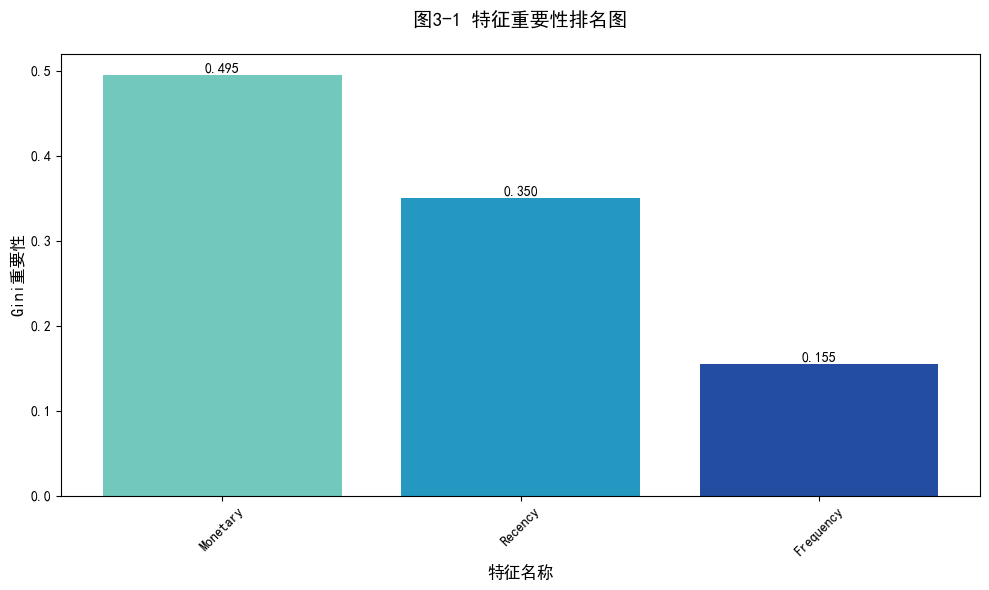

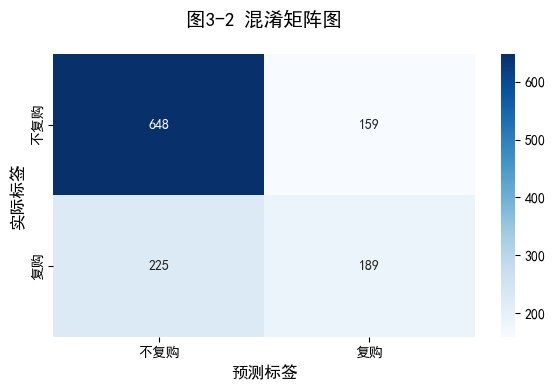

特征重要性分析完成


In [26]:
# =============================================================================
# 9：任务3.2 - 特征重要性分析
# =============================================================================
print("开始任务3.2 特征重要性分析")

# 使用最佳模型的特征重要性
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(len(importances)), importances[indices], 
                   color=plt.cm.YlGnBu(np.linspace(0.4, 0.8, len(importances))))
    plt.xlabel('特征名称', fontsize=12)
    plt.ylabel('Gini重要性', fontsize=12)
    plt.title('图3-1 特征重要性排名图', fontsize=14, pad=20)
    plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=45)
    
    # 添加数值标签
    for i, (bar, imp) in enumerate(zip(bars, importances[indices])):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{imp:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# 混淆矩阵
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['不复购', '复购'], 
            yticklabels=['不复购', '复购'])
plt.xlabel('预测标签', fontsize=12)
plt.ylabel('实际标签', fontsize=12)
plt.title('图3-2 混淆矩阵图', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("特征重要性分析完成")

In [27]:
# =============================================================================
# 10：任务3.3 - 营销策略建议
# =============================================================================
print("开始任务3.3 营销策略")

# 定义各用户群体的营销策略
strategies = {
    '高价值活跃用户': [
        'VIP专属优惠和提前访问权',
        '个性化产品推荐和专属客服', 
        '忠诚度计划升级和积分加倍奖励'
    ],
    '潜力价值用户': [
        '跨品类购买激励和优惠券',
        '会员升级特惠和专属权益',
        '社交分享奖励和邀请机制'
    ],
    '一般价值用户': [
        '常规促销活动精准推送',
        '新品上市优先体验机会',
        '购物车提醒和满减优惠'
    ],
    '流失风险用户': [
        '定向召回优惠券和限时特惠',
        '个性化关怀邮件和短信提醒',
        '流失预警和专属客户经理服务'
    ]
}

# 生成营销策略表
print("分群营销策略表:")
strategy_table = []
for cluster, strategy_list in strategies.items():
    for i, strategy in enumerate(strategy_list):
        strategy_table.append({
            '用户类型': cluster if i == 0 else '',  # 只在第一行显示用户类型
            '推荐营销动作': strategy
        })

strategy_df = pd.DataFrame(strategy_table)
strategy_df.style\
    .set_caption('表3-3 分群营销策略表')\
    .set_properties(**{
        'text-align': 'left', 
        'font-size': '12px',
        'font-family': 'Arial, sans-serif'
    })\
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '16px'), 
            ('font-weight', 'bold'),
            ('color', '#2E4057')
        ]},
        {'selector': 'th', 'props': [
            ('background-color', '#3498DB'), 
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('border', '1px solid #2980B9')
        ]},
        {'selector': 'td', 'props': [
            ('border', '1px solid #BDC3C7')
        ]},
        {'selector': 'tr:nth-child(4n+1)', 'props': [('background-color', '#F8F9F9')]},
        {'selector': 'tr:nth-child(4n+2)', 'props': [('background-color', '#EBF5FB')]},
        {'selector': 'tr:nth-child(4n+3)', 'props': [('background-color', '#F8F9F9')]},
        {'selector': 'tr:nth-child(4n+4)', 'props': [('background-color', '#EBF5FB')]}
    ])

开始任务3.3 营销策略
分群营销策略表:


,用户类型,推荐营销动作
0,高价值活跃用户,VIP专属优惠和提前访问权
1,,个性化产品推荐和专属客服
2,,忠诚度计划升级和积分加倍奖励
3,潜力价值用户,跨品类购买激励和优惠券
4,,会员升级特惠和专属权益
5,,社交分享奖励和邀请机制
6,一般价值用户,常规促销活动精准推送
7,,新品上市优先体验机会
8,,购物车提醒和满减优惠
9,流失风险用户,定向召回优惠券和限时特惠


In [28]:
# =============================================================================
# 11：结果保存
# =============================================================================
print("开始保存结果文件")

# 保存清洗后数据集
df_clean.to_csv('OnlineRetail_cleaned.csv', index=False)

# 保存预测结果文件 - 保持完整信息
predictions = model_data[['CustomerID', 'Recency', 'Frequency', 'Monetary']].copy()
predictions['Repurchase_Probability'] = best_model.predict_proba(X)[:, 1]
predictions['Predicted_Label'] = best_model.predict(X)
predictions['Actual_Label'] = y
predictions.to_csv('prediction_results.csv', index=False)

print("结果文件保存完成")
print("生成文件:")
print("- OnlineRetail_cleaned.csv: 清洗后数据集") 
print("- prediction_results.csv: 模型预测结果文件")

开始保存结果文件
结果文件保存完成
生成文件:
- OnlineRetail_cleaned.csv: 清洗后数据集
- prediction_results.csv: 模型预测结果文件
